# Preprocesamiento y extracción de características biomecánicas

## Configuración inicial y carga de librerías

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    recall_score,
    precision_score
)

from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
MAX_FRAMES = 40

## Selección del ejercicio y vista de análisis

In [ ]:
# MENÚ DE SELECCIÓN


ejercicios = {
    1: "sentadilla",
    2: "peso muerto",
    3: "curl biceps",
    4: "press banca"
}

vistas = {
    1: "frontal",
    2: "lateral"
}

print("EJERCICIOS")
for k, v in ejercicios.items():
    print(f"{k}. {v}")

op_ejercicio = int(input("\nSeleccione un ejercicio: "))
ejercicio = ejercicios[op_ejercicio]

print("\nVISTAS")
for k, v in vistas.items():
    print(f"{k}. {v}")

op_vista = int(input("\nSeleccione una vista: "))
vista = vistas[op_vista]

print("\nConfiguración seleccionada:")
print(f"Ejercicio: {ejercicio}")
print(f"Vista: {vista}")



EJERCICIOS
1. sentadilla
2. peso muerto
3. curl biceps
4. press banca

Seleccione un ejercicio: 1

VISTAS
1. frontal
2. lateral


In [ ]:
CONFIG = {

    # SENTADILLA

    ("sentadilla", "lateral"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/sentadilla_lateral.csv",
        "selected_ids": [12, 24, 26, 28],
        "mode": "angles"
    },

    ("sentadilla", "frontal"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/sentadilla_frontal.csv",
        "selected_ids": [11,12,13,14,15,16,23,24,25,26],
        "mode": "symmetry"
    },

    # PESO MUERTO

    ("peso muerto", "lateral"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/peso_muerto_lateral.csv",
        "selected_ids": [12,14,16,24,26,28],
        "mode": "angles"
    },

    ("peso muerto", "frontal"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/peso_muerto_frontal.csv",
        "selected_ids": [11,12,13,14,15,16,23,24,25,26],
        "mode": "symmetry"
    },

    # CURL BICEPS

    ("curl biceps", "lateral"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/curl_biceps_lateral.csv",
        "selected_ids": [12,14,16,24],
        "mode": "angles"
    },

    ("curl biceps", "frontal"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/curl_biceps_frontal.csv",
        "selected_ids": [11,12,13,14,15,16],
        "mode": "symmetry"
    },

    # PRESS BANCA

    ("press banca", "lateral"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/press_banca_lateral.csv",
        "selected_ids": [12,14,16],
        "mode": "angles"
    },

    ("press banca", "frontal"): {
        "csv": "/content/drive/MyDrive/DATASET_SEPARADOS_TG/press_banca_frontal.csv",
        "selected_ids": [11,12,13,14,15,16],
        "mode": "symmetry"
    }
}

In [ ]:
config = CONFIG[(ejercicio,vista)]

csv_path = config["csv"]
selected_ids = config["selected_ids"]
mode = config["mode"]

## Organización y normalización de landmarks

In [ ]:
df = pd.read_csv(csv_path)

df_pivot = df.pivot_table(
    index=["video","frame"],
    columns="landmark_id",
    values=["x","y","z"]
)

df_pivot.columns = [
    f"{coord}_{lm}"
    for coord,lm in df_pivot.columns
]

df_pivot = df_pivot.reset_index()

In [ ]:
feature_cols = []

for lm in selected_ids:

    for coord in ["x","y","z"]:

        feature_cols.append(
            f"{coord}_{lm}"
        )

df_pivot = df_pivot.fillna(0)

In [ ]:
def normalize_skeleton(row):

    coords = row.values.reshape(-1,3)

    center = coords.mean(axis=0)

    coords = coords - center

    scale = np.linalg.norm(
        coords[0] - coords[-1]
    )

    if scale < 1e-6:
        scale = 1e-6

    coords = coords / scale

    return coords.flatten()

In [ ]:
df_pivot[feature_cols] = df_pivot[
    feature_cols
].apply(
    normalize_skeleton,
    axis=1,
    result_type="expand"
)

## Funciones geométricas

In [ ]:
def calcular_angulo(a, b, c):

    ba = a - b
    bc = c - b

    cos_angle = np.dot(ba, bc) / (
        np.linalg.norm(ba) *
        np.linalg.norm(bc) + 1e-6
    )

    angle = np.arccos(
        np.clip(cos_angle, -1.0, 1.0)
    )

    return np.degrees(angle)

In [ ]:
def calcular_simetria(p1, p2):

    return np.linalg.norm(p1 - p2)

## Extracción de características biomecánicas

### Características para vista lateral

In [ ]:

# FEATURES LATERALES

def extraer_features_laterales(row):

    coords = row.values.reshape(-1,3)

    if ejercicio == "sentadilla":

        shoulder, hip, knee, ankle = coords

        ang_knee = calcular_angulo(
            hip,
            knee,
            ankle
        )

        ang_hip = calcular_angulo(
            shoulder,
            hip,
            knee
        )

        torso_dist = np.linalg.norm(
            shoulder - hip
        )

        return np.array([
            ang_knee,
            ang_hip,
            torso_dist
        ])

    elif ejercicio == "peso muerto":

        shoulder, elbow, hand, hip, knee, ankle = coords

        ang_knee = calcular_angulo(
            hip,
            knee,
            ankle
        )

        ang_hip = calcular_angulo(
            shoulder,
            hip,
            knee
        )

        dist_hand_knee = np.linalg.norm(
            hand - knee
        )

        return np.array([
            ang_knee,
            ang_hip,
            dist_hand_knee
        ])

    elif ejercicio == "curl biceps":

        shoulder, elbow, wrist, hip = coords

        ang_elbow = calcular_angulo(
            shoulder,
            elbow,
            wrist
        )

        dist_elbow_shoulder = np.linalg.norm(
            elbow - shoulder
        )

        dist_elbow_hip = np.linalg.norm(
            elbow - hip
        )

        dist_wrist_shoulder = np.linalg.norm(
            wrist - shoulder
        )

        return np.array([

            ang_elbow,

            dist_elbow_shoulder,

            dist_elbow_hip,

            dist_wrist_shoulder
        ])

    elif ejercicio == "press banca":

      shoulder, elbow, wrist = coords

      ang_elbow = calcular_angulo(
          shoulder,
          elbow,
          wrist
      )

      wrist_dist = np.linalg.norm(
          wrist - shoulder
      )

      return np.array([
          ang_elbow,
          wrist_dist
      ])

### Características para vista frontal

In [ ]:
# FEATURES FRONTALES

def extraer_features_frontales(row):

    coords = row.values.reshape(-1,3)

    if ejercicio == "peso muerto":

        shoulder_l, shoulder_r, elbow_l, elbow_r, hand_l, hand_r,hip_l, hip_r, knee_l, knee_r = coords

        shoulder_sym = calcular_simetria(
            shoulder_l,
            shoulder_r
        )

        hip_sym = calcular_simetria(
            hip_l,
            hip_r
        )

        knee_sym = calcular_simetria(
            knee_l,
            knee_r
        )

        shoulder_height_diff = abs(
            shoulder_l[1] - shoulder_r[1]
        )

        hip_height_diff = abs(
            hip_l[1] - hip_r[1]
        )

        knee_height_diff = abs(
            knee_l[1] - knee_r[1]
        )

        hand_height_diff = abs(
            hand_l[1] - hand_r[1]
        )

        shoulder_tilt = np.degrees(
            np.arctan2(
                shoulder_r[1]-shoulder_l[1],
                shoulder_r[0]-shoulder_l[0]
            )
        )

        hip_tilt = np.degrees(
            np.arctan2(
                hip_r[1]-hip_l[1],
                hip_r[0]-hip_l[0]
            )
        )

        bar_tilt = np.degrees(
            np.arctan2(
                hand_r[1]-hand_l[1],
                hand_r[0]-hand_l[0]
            )
        )

        arm_left = np.linalg.norm(
            shoulder_l - hand_l
        )

        arm_right = np.linalg.norm(
            shoulder_r - hand_r
        )


        arm_asymmetry = abs(
            arm_left - arm_right
        )

        leg_left = np.linalg.norm(
            hip_l - knee_l
        )

        leg_right = np.linalg.norm(
            hip_r - knee_r
        )

        leg_asymmetry = abs(
            leg_left - leg_right
        )

        center_shoulders = (
            shoulder_l + shoulder_r
        ) / 2

        center_hips = (
            hip_l + hip_r
        ) / 2

        lateral_shift = abs(
            center_shoulders[0]
            -
            center_hips[0]
        )

        return np.array([

            shoulder_sym,

            hip_sym,

            knee_sym,

            shoulder_height_diff,

            hip_height_diff,

            knee_height_diff,

            hand_height_diff,

            shoulder_tilt,

            hip_tilt,

            bar_tilt,

            arm_asymmetry,

            leg_asymmetry,

            lateral_shift

        ])


    elif ejercicio == "sentadilla":

        shoulder_l, shoulder_r, elbow_l, elbow_r, hand_l, hand_r,hip_l, hip_r, knee_l, knee_r = coords

        shoulder_sym = calcular_simetria(
            shoulder_l,
            shoulder_r
        )

        hip_sym = calcular_simetria(
            hip_l,
            hip_r
        )

        knee_sym = calcular_simetria(
            knee_l,
            knee_r
        )

        knee_height_diff = abs(
            knee_l[1] - knee_r[1]
        )

        hip_height_diff = abs(
            hip_l[1] - hip_r[1]
        )

        shoulder_height_diff = abs(
            shoulder_l[1] - shoulder_r[1]
        )

        shoulder_tilt = np.degrees(
            np.arctan2(
                shoulder_r[1]-shoulder_l[1],
                shoulder_r[0]-shoulder_l[0]
            )
        )

        hip_tilt = np.degrees(
            np.arctan2(
                hip_r[1]-hip_l[1],
                hip_r[0]-hip_l[0]
            )
        )

        knee_hip_l = np.linalg.norm(
            knee_l - hip_l
        )

        knee_hip_r = np.linalg.norm(
            knee_r - hip_r
        )

        depth_diff = abs(
            knee_hip_l -
            knee_hip_r
        )


        return np.array([
            shoulder_sym,

            hip_sym,

            knee_sym,

            shoulder_height_diff,

            hip_height_diff,

            knee_height_diff,

            shoulder_tilt,

            hip_tilt,

            depth_diff

        ])


    elif ejercicio in [
        "curl biceps",
        "press banca"
    ]:

        shoulder_l, shoulder_r, elbow_l, elbow_r, wrist_l, wrist_r = coords

        shoulder_sym = calcular_simetria(
            shoulder_l,
            shoulder_r
        )

        elbow_sym = calcular_simetria(
            elbow_l,
            elbow_r
        )

        wrist_sym = calcular_simetria(
            wrist_l,
            wrist_r
        )

        wrist_height_diff = abs(
            wrist_l[1] - wrist_r[1]
        )

        ang_left = calcular_angulo(
            shoulder_l,
            elbow_l,
            wrist_l
        )

        ang_right = calcular_angulo(
            shoulder_r,
            elbow_r,
            wrist_r
        )

        angle_diff = abs(
            ang_left - ang_right
        )

        return np.array([
            shoulder_sym,
            elbow_sym,
            wrist_sym,
            wrist_height_diff,
            angle_diff
        ])

## Construcción del conjunto de características

In [ ]:
# EXTRAER FEATURES

if mode == "angles":

    features = df_pivot[
        feature_cols
    ].apply(
        extraer_features_laterales,
        axis=1,
        result_type="expand"
    )

else:

    features = df_pivot[
        feature_cols
    ].apply(
        extraer_features_frontales,
        axis=1,
        result_type="expand"
    )

In [ ]:
# NOMBRES FEATURES

FEATURE_NAMES = {

    ("sentadilla", "lateral"): [
        "angulo_rodilla",
        "angulo_cadera",
        "distancia_torso"
    ],

    ("sentadilla", "frontal"): [
        "simetria_hombros",
        "simetria_caderas",
        "simetria_rodillas",
        "dif_altura_hombros",
        "dif_altura_caderas",
        "dif_altura_rodillas",
        "inclinacion_hombros",
        "inclinacion_caderas",
        "diferencia_profundidad"
    ],

    ("peso muerto", "lateral"): [
        "angulo_rodilla",
        "angulo_cadera",
        "distancia_mano_rodilla"
    ],

    ("peso muerto", "frontal"): [
        "simetria_hombros",
        "simetria_caderas",
        "simetria_rodillas",
        "dif_altura_hombros",
        "dif_altura_caderas",
        "dif_altura_rodillas",
        "dif_altura_manos",
        "inclinacion_hombros",
        "inclinacion_caderas",
        "inclinacion_barra",
        "asimetria_brazos",
        "asimetria_piernas",
        "desplazamiento_lateral"
    ],

    ("curl biceps", "lateral"): [
        "angulo_codo",
        "distancia_codo_hombro",
        "distancia_codo_cadera",
        "distancia_muneca_hombro"
    ],

    ("curl biceps", "frontal"): [
        "simetria_hombros",
        "simetria_codos",
        "simetria_munecas",
        "dif_altura_munecas",
        "diferencia_angulos_codo"
    ],

    ("press banca", "lateral"): [
        "angulo_codo",
        "distancia_muneca_hombro"
    ],

    ("press banca", "frontal"): [
        "simetria_hombros",
        "simetria_codos",
        "simetria_munecas",
        "dif_altura_munecas",
        "diferencia_angulos_codo"
    ]
}

features.columns = FEATURE_NAMES[(ejercicio, vista)]

In [ ]:
# AGREGAR FEATURES

df_pivot = pd.concat(
    [df_pivot, features],
    axis=1
)

temporal_features = list(
    features.columns
)

## Etiquetado de videos y participantes

In [ ]:
def get_label(video):

    return (
        1 if "bien" in video.lower()
        else 0
    )

def get_person(video):

    return video.split("_")[1]

df_pivot["label"] = df_pivot["video"].apply(get_label)

df_pivot["person"] = df_pivot["video"].apply(get_person)

# Construcción del modelo biomecánico de referencia

## Definición de funciones de evaluación biomecánica

In [ ]:
def construir_modelo_biomecanico(
    df_pivot,
    ejercicio,
    vista
):

    videos_bien = df_pivot[
        df_pivot["video"]
        .str.lower()
        .str.contains("bien")
    ]["video"].unique()

    referencias = []

    for video in videos_bien:

        data = df_pivot[
            df_pivot["video"] == video
        ]

        # SENTADILLA LATERAL

        if ejercicio == "sentadilla" and vista == "lateral":

            referencias.append({

                "angulo_min_rodilla":
                data["angulo_rodilla"].min(),

                "angulo_min_cadera":
                data["angulo_cadera"].min(),

                "longitud_torso":
                data["distancia_torso"].mean()
            })

        # SENTADILLA FRONTAL

        elif ejercicio == "sentadilla" and vista == "frontal":

            referencias.append({

                "simetria_hombros":
                data["simetria_hombros"].mean(),

                "simetria_caderas":
                data["simetria_caderas"].mean(),

                "simetria_rodillas":
                data["simetria_rodillas"].mean(),

                "max_dif_altura_hombros":
                data["dif_altura_hombros"].max(),

                "max_dif_altura_caderas":
                data["dif_altura_caderas"].max(),

                "max_dif_altura_rodillas":
                data["dif_altura_rodillas"].max(),

                "max_inclinacion_hombros":
                np.abs(
                    data["inclinacion_hombros"]
                ).max(),

                "max_inclinacion_caderas":
                np.abs(
                    data["inclinacion_caderas"]
                ).max(),

                "max_diferencia_profundidad":
                data["diferencia_profundidad"].max()
            })

        # PESO MUERTO LATERAL

        elif ejercicio == "peso muerto" and vista == "lateral":

            referencias.append({

                "angulo_min_rodilla":
                data["angulo_rodilla"].min(),

                "angulo_min_cadera":
                data["angulo_cadera"].min(),

                "distancia_mano_rodilla":
                data["distancia_mano_rodilla"].min()
            })

        # PESO MUERTO FRONTAL

        elif ejercicio == "peso muerto" and vista == "frontal":

            referencias.append({

                "simetria_hombros":
                data["simetria_hombros"].mean(),

                "simetria_caderas":
                data["simetria_caderas"].mean(),

                "simetria_rodillas":
                data["simetria_rodillas"].mean(),

                "max_dif_altura_hombros":
                data["dif_altura_hombros"].max(),

                "max_dif_altura_caderas":
                data["dif_altura_caderas"].max(),

                "max_dif_altura_rodillas":
                data["dif_altura_rodillas"].max(),

                "max_dif_altura_manos":
                data["dif_altura_manos"].max(),

                "max_inclinacion_hombros":
                np.abs(
                    data["inclinacion_hombros"]
                ).max(),

                "max_inclinacion_caderas":
                np.abs(
                    data["inclinacion_caderas"]
                ).max(),

                "max_inclinacion_barra":
                np.abs(
                    data["inclinacion_barra"]
                ).max(),

                "max_asimetria_brazos":
                data["asimetria_brazos"].max(),

                "max_asimetria_piernas":
                data["asimetria_piernas"].max(),

                "max_desplazamiento_lateral":
                data["desplazamiento_lateral"].max()
            })

        # CURL BICEPS LATERAL

        elif ejercicio == "curl biceps" and vista == "lateral":

            angulo_codo = data["angulo_codo"]

            vel_codo = np.diff(
                angulo_codo
            )

            referencias.append({

                "angulo_min_codo":
                angulo_codo.min(),

                "angulo_max_codo":
                angulo_codo.max(),

                "rom_codo":
                angulo_codo.max()
                -
                angulo_codo.min(),

                "std_angulo_codo":
                angulo_codo.std(),

                "distancia_media_codo_hombro":
                data["distancia_codo_hombro"].mean(),

                "std_codo_hombro":
                data["distancia_codo_hombro"].std(),

                "distancia_media_codo_cadera":
                data["distancia_codo_cadera"].mean(),

                "std_codo_cadera":
                data["distancia_codo_cadera"].std(),

                "std_muneca_hombro":
                data["distancia_muneca_hombro"].std(),

                "velocidad_media_codo":
                np.mean(
                    np.abs(vel_codo)
                )
            })

        # CURL BICEPS FRONTAL

        elif ejercicio == "curl biceps" and vista == "frontal":

            referencias.append({

                "simetria_hombros":
                data["simetria_hombros"].mean(),

                "simetria_codos":
                data["simetria_codos"].mean(),

                "simetria_munecas":
                data["simetria_munecas"].mean(),

                "max_dif_altura_munecas":
                data["dif_altura_munecas"].max(),

                "max_diferencia_angulos":
                data["diferencia_angulos_codo"].max()
            })

        # PRESS BANCA LATERAL

        elif ejercicio == "press banca" and vista == "lateral":

            angulo_codo = data["angulo_codo"]

            distancia_muneca_hombro = (
                data["distancia_muneca_hombro"]
            )

            velocidad_codo = np.diff(
                angulo_codo
            )

            angulo_codo = data["angulo_codo"]

            vel_codo = np.diff(
                angulo_codo
            )

            idx_bottom = data["y_16"].idxmax()

            x_hombro_bottom = data.loc[
                idx_bottom,
                "x_12"
            ]

            y_hombro_bottom = data.loc[
                idx_bottom,
                "y_12"
            ]

            x_muneca_bottom = data.loc[
                idx_bottom,
                "x_16"
            ]

            y_muneca_bottom = data.loc[
                idx_bottom,
                "y_16"
            ]

            desplazamiento_horizontal_barra = abs(
                x_muneca_bottom -
                x_hombro_bottom
            )

            profundidad_descenso = abs(
                y_muneca_bottom -
                y_hombro_bottom
            )

            ratio_pecho_abdomen = (
                desplazamiento_horizontal_barra
                /
                (profundidad_descenso + 1e-6)
            )

            trayectoria_horizontal_barra = (
                data["x_16"].max()
                -
                data["x_16"].min()
            )

            referencias.append({

                "angulo_min_codo":
                angulo_codo.min(),

                "angulo_max_codo":
                angulo_codo.max(),

                "rom_codo":
                angulo_codo.max() - angulo_codo.min(),

                "std_angulo_codo":
                angulo_codo.std(),

                "distancia_media_muneca_hombro":
                distancia_muneca_hombro.mean(),

                "std_distancia_muneca_hombro":
                distancia_muneca_hombro.std(),

                "desplazamiento_codo":
                np.sqrt(
                    (data["x_14"].max()-data["x_14"].min())**2 +
                    (data["y_14"].max()-data["y_14"].min())**2
                ),

                "desplazamiento_muneca":
                np.sqrt(
                    (data["x_16"].max()-data["x_16"].min())**2 +
                    (data["y_16"].max()-data["y_16"].min())**2
                ),

                "velocidad_media_codo":
                np.mean(np.abs(velocidad_codo)),

                "velocidad_maxima_codo":
                np.max(np.abs(velocidad_codo)),

                "aceleracion_media":
                np.mean(
                    np.abs(
                        np.diff(angulo_codo, n=2)
                    )
                ),

                "desplazamiento_horizontal_barra":
                desplazamiento_horizontal_barra,

                "profundidad_descenso":
                profundidad_descenso,

                "ratio_pecho_abdomen":
                ratio_pecho_abdomen,

                "trayectoria_horizontal_barra":
                trayectoria_horizontal_barra
            })

        # PRESS BANCA FRONTAL

        elif ejercicio == "press banca" and vista == "frontal":

            referencias.append({

                "simetria_hombros":
                data["simetria_hombros"].mean(),

                "simetria_codos":
                data["simetria_codos"].mean(),

                "simetria_munecas":
                data["simetria_munecas"].mean(),

                "max_dif_altura_munecas":
                data["dif_altura_munecas"].max(),

                "max_diferencia_angulos":
                data["diferencia_angulos_codo"].max()
            })

    modelo_biomecanico = pd.DataFrame(
        referencias
    )

    modelo_referencia = pd.DataFrame({

        "Parametro":
        modelo_biomecanico.columns,

        "Valor ideal":
        modelo_biomecanico.mean().values,

        "STD":
        modelo_biomecanico.std().values,

        "Limite inferior":
        (
            modelo_biomecanico.mean()
            -
            modelo_biomecanico.std()
        ).values,

        "Limite superior":
        (
            modelo_biomecanico.mean()
            +
            modelo_biomecanico.std()
        ).values
    })

    return modelo_referencia

In [ ]:
# COMPARACIÓN CONTRA MODELO DE REFERENCIA

def comparar_con_modelo(
    valores_video,
    modelo_referencia
):

    resultados = []

    score_total = []

    for _, row in modelo_referencia.iterrows():

        parametro = row["Parametro"]

        ideal = row["Valor ideal"]

        inferior = row["Limite inferior"]

        superior = row["Limite superior"]

        valor = valores_video[parametro]

        desviacion = abs(
            valor - ideal
        )

        cumple = (
            inferior <= valor <= superior
        )

        score = max(
            0,
            100 *
            (
                1 -
                desviacion /
                (abs(ideal)+1e-6)
            )
        )

        score_total.append(score)

        resultados.append({

            "Parametro": parametro,

            "Valor observado": valor,

            "Valor ideal": ideal,

            "Limite inferior": inferior,

            "Limite superior": superior,

            "Desviacion": desviacion,

            "Cumple": cumple,

            "Score": score
        })

    resultados = pd.DataFrame(
        resultados
    )

    score_global = np.mean(
        score_total
    )

    return resultados, score_global

In [ ]:
def extraer_indicadores_video(
    data,
    ejercicio,
    vista
):

    # SENTADILLA LATERAL

    if ejercicio == "sentadilla" and vista == "lateral":

        return {

            "angulo_min_rodilla":
            data["angulo_rodilla"].min(),

            "angulo_min_cadera":
            data["angulo_cadera"].min(),

            "longitud_torso":
            data["distancia_torso"].mean()
        }

    # SENTADILLA FRONTAL

    elif ejercicio == "sentadilla" and vista == "frontal":

        return {

            "simetria_hombros":
            data["simetria_hombros"].mean(),

            "simetria_caderas":
            data["simetria_caderas"].mean(),

            "simetria_rodillas":
            data["simetria_rodillas"].mean(),

            "max_dif_altura_hombros":
            data["dif_altura_hombros"].max(),

            "max_dif_altura_caderas":
            data["dif_altura_caderas"].max(),

            "max_dif_altura_rodillas":
            data["dif_altura_rodillas"].max(),

            "max_inclinacion_hombros":
            np.abs(
                data["inclinacion_hombros"]
            ).max(),

            "max_inclinacion_caderas":
            np.abs(
                data["inclinacion_caderas"]
            ).max(),

            "max_diferencia_profundidad":
            data["diferencia_profundidad"].max()
        }

    # PESO MUERTO LATERAL

    elif ejercicio == "peso muerto" and vista == "lateral":

        return {

            "angulo_min_rodilla":
            data["angulo_rodilla"].min(),

            "angulo_min_cadera":
            data["angulo_cadera"].min(),

            "distancia_mano_rodilla":
            data["distancia_mano_rodilla"].min()
        }

    # PESO MUERTO FRONTAL

    elif ejercicio == "peso muerto" and vista == "frontal":

        return {

            "simetria_hombros":
            data["simetria_hombros"].mean(),

            "simetria_caderas":
            data["simetria_caderas"].mean(),

            "simetria_rodillas":
            data["simetria_rodillas"].mean(),

            "max_dif_altura_hombros":
            data["dif_altura_hombros"].max(),

            "max_dif_altura_caderas":
            data["dif_altura_caderas"].max(),

            "max_dif_altura_rodillas":
            data["dif_altura_rodillas"].max(),

            "max_dif_altura_manos":
            data["dif_altura_manos"].max(),

            "max_inclinacion_hombros":
            np.abs(
                data["inclinacion_hombros"]
            ).max(),

            "max_inclinacion_caderas":
            np.abs(
                data["inclinacion_caderas"]
            ).max(),

            "max_inclinacion_barra":
            np.abs(
                data["inclinacion_barra"]
            ).max(),

            "max_asimetria_brazos":
            data["asimetria_brazos"].max(),

            "max_asimetria_piernas":
            data["asimetria_piernas"].max(),

            "max_desplazamiento_lateral":
            data["desplazamiento_lateral"].max()
        }

    # CURL BICEPS LATERAL

    elif ejercicio == "curl biceps" and vista == "lateral":

        angulo_codo = data["angulo_codo"]

        vel_codo = np.diff(
            angulo_codo
        )

        return{

            "angulo_min_codo":
            angulo_codo.min(),

            "angulo_max_codo":
            angulo_codo.max(),

            "rom_codo":
            angulo_codo.max()
            -
            angulo_codo.min(),

            "std_angulo_codo":
            angulo_codo.std(),

            "distancia_media_codo_hombro":
            data["distancia_codo_hombro"].mean(),

            "std_codo_hombro":
            data["distancia_codo_hombro"].std(),

            "distancia_media_codo_cadera":
            data["distancia_codo_cadera"].mean(),

            "std_codo_cadera":
            data["distancia_codo_cadera"].std(),

            "std_muneca_hombro":
            data["distancia_muneca_hombro"].std(),

            "velocidad_media_codo":
            np.mean(
                np.abs(vel_codo)
            )
        }

    # CURL BICEPS FRONTAL

    elif ejercicio == "curl biceps" and vista == "frontal":

        return {

            "simetria_hombros":
            data["simetria_hombros"].mean(),

            "simetria_codos":
            data["simetria_codos"].mean(),

            "simetria_munecas":
            data["simetria_munecas"].mean(),

            "max_dif_altura_munecas":
            data["dif_altura_munecas"].max(),

            "max_diferencia_angulos":
            data["diferencia_angulos_codo"].max()
        }

    # PRESS BANCA LATERAL

    elif ejercicio == "press banca" and vista == "lateral":

        angulo_codo = data["angulo_codo"]

        distancia_muneca_hombro = (
            data["distancia_muneca_hombro"]
        )

        velocidad_codo = np.diff(
            angulo_codo
        )

        angulo_codo = data["angulo_codo"]

        vel_codo = np.diff(
            angulo_codo
        )

        idx_bottom = data["y_16"].idxmax()

        x_hombro_bottom = data.loc[
            idx_bottom,
            "x_12"
        ]

        y_hombro_bottom = data.loc[
            idx_bottom,
            "y_12"
        ]

        x_muneca_bottom = data.loc[
            idx_bottom,
            "x_16"
        ]

        y_muneca_bottom = data.loc[
            idx_bottom,
            "y_16"
        ]

        desplazamiento_horizontal_barra = abs(
            x_muneca_bottom -
            x_hombro_bottom
        )

        profundidad_descenso = abs(
            y_muneca_bottom -
            y_hombro_bottom
        )

        ratio_pecho_abdomen = (
            desplazamiento_horizontal_barra
            /
            (profundidad_descenso + 1e-6)
        )

        trayectoria_horizontal_barra = (
            data["x_16"].max()
            -
            data["x_16"].min()
        )

        return {

            "angulo_min_codo":
            angulo_codo.min(),

            "angulo_max_codo":
            angulo_codo.max(),

            "rom_codo":
            angulo_codo.max() - angulo_codo.min(),

            "std_angulo_codo":
            angulo_codo.std(),

            "distancia_media_muneca_hombro":
            distancia_muneca_hombro.mean(),

            "std_distancia_muneca_hombro":
            distancia_muneca_hombro.std(),

            "desplazamiento_codo":
            np.sqrt(
                (data["x_14"].max()-data["x_14"].min())**2 +
                (data["y_14"].max()-data["y_14"].min())**2
            ),

            "desplazamiento_muneca":
            np.sqrt(
                (data["x_16"].max()-data["x_16"].min())**2 +
                (data["y_16"].max()-data["y_16"].min())**2
            ),

            "velocidad_media_codo":
            np.mean(np.abs(velocidad_codo)),

            "velocidad_maxima_codo":
            np.max(np.abs(velocidad_codo)),

            "aceleracion_media":
            np.mean(
                np.abs(
                    np.diff(angulo_codo, n=2)
                )
            ),

            "desplazamiento_horizontal_barra":
            desplazamiento_horizontal_barra,

            "profundidad_descenso":
            profundidad_descenso,

            "ratio_pecho_abdomen":
            ratio_pecho_abdomen,

            "trayectoria_horizontal_barra":
            trayectoria_horizontal_barra
        }

    # PRESS BANCA FRONTAL

    elif ejercicio == "press banca" and vista == "frontal":

        return {

            "simetria_hombros":
            data["simetria_hombros"].mean(),

            "simetria_codos":
            data["simetria_codos"].mean(),

            "simetria_munecas":
            data["simetria_munecas"].mean(),

            "max_dif_altura_munecas":
            data["dif_altura_munecas"].max(),

            "max_diferencia_angulos":
            data["diferencia_angulos_codo"].max()
        }

In [ ]:
# ============================================================
# CLASIFICACIÓN DE CALIDAD
# ============================================================

def clasificar_calidad(score):

    if score >= 90:
        return "Excelente"

    elif score >= 75:
        return "Buena"

    elif score >= 60:
        return "Regular"

    else:
        return "Deficiente"

In [ ]:
# ============================================================
# ACIERTOS DEL SISTEMA
# ============================================================

def es_correcto(real, calidad):

    if real == "bien":

        return calidad in [
            "Excelente",
            "Buena"
        ]

    else:

        return calidad in [
            "Regular",
            "Deficiente"
        ]


## Generación del modelo biomecánico de referencia

In [ ]:
# MODELO BIOMECÁNICO DE REFERENCIA
# SOLO VIDEOS "BIEN"

videos_bien = df_pivot[
    df_pivot["video"].str.lower().str.contains("bien")
]["video"].unique()

referencias = []

In [ ]:
modelo_referencia = construir_modelo_biomecanico(
    df_pivot,
    ejercicio,
    vista
)

display(
    modelo_referencia.round(2)
)

,Parametro,Valor ideal,STD,Limite inferior,Limite superior
0,simetria_hombros,0.52,0.04,0.48,0.56
1,simetria_caderas,0.31,0.02,0.29,0.34
2,simetria_rodillas,0.63,0.05,0.58,0.68
3,max_dif_altura_hombros,0.02,0.00,0.01,0.02
4,max_dif_altura_caderas,0.01,0.00,0.01,0.01
5,max_dif_altura_rodillas,0.03,0.01,0.02,0.03
6,max_inclinacion_hombros,179.98,0.04,179.94,180.02
7,max_inclinacion_caderas,179.91,0.20,179.72,180.11
8,max_diferencia_profundidad,0.23,0.09,0.14,0.32


## Construcción del dataset biomecánico

In [ ]:
# DATASET BASADO EN MÉTRICAS BIOMECÁNICAS

def create_dataset_biomecanico(
    df_pivot,
    modelo_referencia,
    ejercicio,
    vista
):

    X = []
    y = []
    groups = []

    for video in df_pivot["video"].unique():

        data_video = df_pivot[
            df_pivot["video"] == video
        ]

        indicadores = extraer_indicadores_video(
            data_video,
            ejercicio,
            vista
        )

        feature_vector = []

        cumple_total = 0

        for _, row in modelo_referencia.iterrows():

            parametro = row["Parametro"]

            ideal = row["Valor ideal"]

            inferior = row["Limite inferior"]

            superior = row["Limite superior"]

            valor = indicadores[parametro]

            desviacion = abs(
                valor - ideal
            )

            desviacion_relativa = (
                desviacion /
                (abs(ideal) + 1e-6)
            )

            cumple = int(
                inferior <= valor <= superior
            )

            feature_vector.extend([

                valor,

                desviacion,

                desviacion_relativa,

                cumple
            ])

            cumple_total += cumple

        porcentaje_cumplimiento = (
            cumple_total /
            len(modelo_referencia)
        )

        _, score_global = comparar_con_modelo(
            indicadores,
            modelo_referencia
        )

        feature_vector.extend([

            score_global,

            porcentaje_cumplimiento

        ])

        X.append(feature_vector)

        y.append(
            1 if "bien" in video.lower()
            else 0
        )

        groups.append(
            data_video["person"].iloc[0]
        )

    return (
        np.array(X),
        np.array(y),
        np.array(groups)
    )

In [ ]:
# DATASET BIOMECÁNICO

X_ml, y_ml, groups_ml = create_dataset_biomecanico(

    df_pivot,

    modelo_referencia,

    ejercicio,

    vista
)

print("Shape dataset biomecánico:")
print(X_ml.shape)

Shape dataset biomecánico:
(280, 38)


## Comparación de un video con el modelo de referencia

In [ ]:
# SELECCION DE VIDEO ALEATORIO

tipo_video = "mal"

if tipo_video == "bien":

    videos_disponibles = df_pivot[
        df_pivot["video"]
        .str.lower()
        .str.contains("bien")
    ]["video"].unique()

elif tipo_video == "mal":

    videos_disponibles = df_pivot[
        df_pivot["video"]
        .str.lower()
        .str.contains("mal")
    ]["video"].unique()

else:

    raise ValueError(
        "tipo_video debe ser 'bien' o 'mal'"
    )

video_prueba = np.random.choice(
    videos_disponibles
)

print(f"Video seleccionado ({tipo_video}):")
print(video_prueba)

data_video = df_pivot[
    df_pivot["video"] == video_prueba
]

Video seleccionado (mal):
2_AchipizDaniel_Sentadilla_Frontal_Mal_Rep_2.mp4


In [ ]:
# INDICADORES DEL VIDEO

valores_video = extraer_indicadores_video(
    data_video,
    ejercicio,
    vista
)

display(
    pd.DataFrame(
        valores_video.items(),
        columns=["Parametro","Valor observado"]
    )
)

,Parametro,Valor observado
0,simetria_hombros,0.566290
1,simetria_caderas,0.333798
2,simetria_rodillas,0.564926
3,max_dif_altura_hombros,0.030029
4,max_dif_altura_caderas,0.009640
5,max_dif_altura_rodillas,0.033370
6,max_inclinacion_hombros,179.994163
7,max_inclinacion_caderas,179.996874
8,max_diferencia_profundidad,0.535017


In [ ]:
# COMPARACIÓN

detalle, score_global = comparar_con_modelo(
    valores_video,
    modelo_referencia
)

display(
    detalle.round(2)
)

print(
    f"\nCalidad biomecánica: "
    f"{score_global:.2f}%"
)

,Parametro,Valor observado,Valor ideal,Limite inferior,Limite superior,Desviacion,Cumple,Score
0,simetria_hombros,0.57,0.52,0.48,0.56,0.05,False,91.07
1,simetria_caderas,0.33,0.31,0.29,0.34,0.02,True,93.87
2,simetria_rodillas,0.56,0.63,0.58,0.68,0.07,False,89.66
3,max_dif_altura_hombros,0.03,0.02,0.01,0.02,0.01,False,4.80
4,max_dif_altura_caderas,0.01,0.01,0.01,0.01,0.00,True,89.23
5,max_dif_altura_rodillas,0.03,0.03,0.02,0.03,0.01,True,74.69
6,max_inclinacion_hombros,179.99,179.98,179.94,180.02,0.01,True,99.99
7,max_inclinacion_caderas,180.00,179.91,179.72,180.11,0.08,True,99.95
8,max_diferencia_profundidad,0.54,0.23,0.14,0.32,0.30,False,0.00



Calidad biomecánica: 71.48%


In [ ]:
# CLASIFICACIÓN DE CALIDAD (BASICA)

if score_global >= 90:
    calidad = "Excelente"

elif score_global >= 75:
    calidad = "Buena"

elif score_global >= 60:
    calidad = "Regular"

else:
    calidad = "Deficiente"

print(
    f"Clasificación: {calidad}"
)

Clasificación: Regular


## Validación del modelo biomecánico

In [ ]:
# VALIDACIÓN DEL MODELO BIOMECÁNICO

resultados_validacion = []

videos = df_pivot["video"].unique()

for video in videos:

    data_video = df_pivot[
        df_pivot["video"] == video
    ]

    valores_video = extraer_indicadores_video(
        data_video,
        ejercicio,
        vista
    )

    detalle, score_global = comparar_con_modelo(
        valores_video,
        modelo_referencia
    )

    calidad = clasificar_calidad(
        score_global
    )

    etiqueta_real = (
        "bien"
        if "bien" in video.lower()
        else "mal"
    )

    resultados_validacion.append({

        "video": video,

        "real": etiqueta_real,

        "score": score_global,

        "calidad": calidad
    })

resultados_validacion = pd.DataFrame(
    resultados_validacion
)

display(
    resultados_validacion.sort_values(
        "score",
        ascending=False
    )
)

,video,real,score,calidad
182,2_HenaoCatalina_Sentadilla_Frontal_Bien_Rep_3.mp4,bien,94.357825,Excelente
42,1_HenaoCatalina_Sentadilla_Frontal_Bien_Rep_3.mp4,bien,94.185980,Excelente
32,1_GongoraSebastian_Sentadilla_Frontal_Bien_Rep...,bien,93.992437,Excelente
60,1_JimenezRonaldo_Sentadilla_Frontal_Bien_Rep_1...,bien,93.911292,Excelente
191,2_HomeCamilo_Sentadilla_Frontal_Bien_Rep_2.mp4,bien,93.876845,Excelente
...,...,...,...,...
156,2_CuajiDaniel_Sentadilla_Frontal_Mal_Rep_2.mp4,mal,51.357153,Deficiente
119,1_RodriguezGregory_Sentadilla_Frontal_Mal_Rep_...,mal,51.155756,Deficiente
155,2_CuajiDaniel_Sentadilla_Frontal_Mal_Rep_1.mp4,mal,50.639812,Deficiente
158,2_CuajiDaniel_Sentadilla_Frontal_Mal_Rep_4.mp4,mal,48.839759,Deficiente


In [ ]:
resultados_validacion["acierto"] = (

    resultados_validacion.apply(

        lambda row:
        es_correcto(
            row["real"],
            row["calidad"]
        ),

        axis=1
    )
)

Accuracy biomecanico

In [ ]:
# RESULTADOS GENERALES

total = len(
    resultados_validacion
)

aciertos = resultados_validacion[
    "acierto"
].sum()

accuracy_biomecanico = (

    aciertos / total
)

print(
    f"Aciertos: {aciertos}/{total}"
)

print(
    f"Accuracy biomecánico: "
    f"{accuracy_biomecanico:.2%}"
)

Aciertos: 239/280
Accuracy biomecánico: 85.36%


In [ ]:
bien = resultados_validacion[
    resultados_validacion["real"] == "bien"
]

bien_correctos = bien[
    "acierto"
].sum()

print(
    f"Videos BIEN correctamente detectados: "
    f"{bien_correctos}/{len(bien)}"
)

print(
    f"Tasa de acierto BIEN: "
    f"{100*bien_correctos/len(bien):.2f}%"
)

Videos BIEN correctamente detectados: 137/140
Tasa de acierto BIEN: 97.86%


In [ ]:
mal = resultados_validacion[
    resultados_validacion["real"] == "mal"
]

mal_correctos = mal[
    "acierto"
].sum()

print(
    f"Videos MAL correctamente detectados: "
    f"{mal_correctos}/{len(mal)}"
)

print(
    f"Tasa de acierto MAL: "
    f"{100*mal_correctos/len(mal):.2f}%"
)

Videos MAL correctamente detectados: 102/140
Tasa de acierto MAL: 72.86%


Visualizacion matriz de confusion

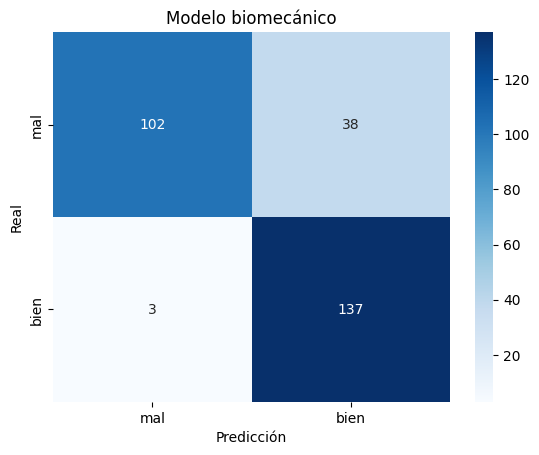

In [ ]:
from sklearn.metrics import confusion_matrix

pred = []

for calidad in resultados_validacion["calidad"]:

    if calidad in [
        "Excelente",
        "Buena"
    ]:

        pred.append("bien")

    else:

        pred.append("mal")

cm = confusion_matrix(

    resultados_validacion["real"],
    pred,

    labels=["mal","bien"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",

    xticklabels=["mal","bien"],
    yticklabels=["mal","bien"]
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Modelo biomecánico")
plt.show()

# Entrenamiento y evaluación de clasificadores

## Funcion de evaluacion de modelos

In [ ]:
from sklearn.metrics import log_loss

In [ ]:
def evaluate_ml_model(
    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test
):

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(
        X_test
    )

    acc = accuracy_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )



    print("\n========================")
    print(model_name)
    print("========================")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(4,3))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Matriz - {model_name}"
    )

    plt.show()

    return {

        "Model": model_name,

        "Accuracy": acc,

        "F1-Score": f1,

        "MCC": mcc,

        "Recall": recall,

        "Precision": precision
    }

In [ ]:
def evaluate_ml_model(
    model,
    model_name,
    X_train,
    X_test,
    y_train,
    y_test
):

    # ======================================================
    # ENTRENAMIENTO
    # ======================================================

    model.fit(
        X_train,
        y_train
    )

    # ======================================================
    # PREDICCIONES
    # ======================================================

    y_pred_train = model.predict(
        X_train
    )

    y_pred_test = model.predict(
        X_test
    )

    # ======================================================
    # ACCURACY
    # ======================================================

    train_acc = accuracy_score(
        y_train,
        y_pred_train
    )

    test_acc = accuracy_score(
        y_test,
        y_pred_test
    )

    # ======================================================
    # LOSS
    # ======================================================

    if hasattr(model, "predict_proba"):

        y_prob_train = model.predict_proba(
            X_train
        )

        y_prob_test = model.predict_proba(
            X_test
        )

        train_loss = log_loss(
            y_train,
            y_prob_train
        )

        test_loss = log_loss(
            y_test,
            y_prob_test
        )

    else:

        train_loss = np.nan
        test_loss = np.nan

    # ======================================================
    # MÉTRICAS DE TEST
    # ======================================================

    f1 = f1_score(
        y_test,
        y_pred_test
    )

    mcc = matthews_corrcoef(
        y_test,
        y_pred_test
    )

    recall = recall_score(
        y_test,
        y_pred_test
    )

    precision = precision_score(
        y_test,
        y_pred_test
    )

    # ======================================================
    # REPORTE
    # ======================================================

    print("\n========================")
    print(model_name)
    print("========================")

    print(
        f"Train Accuracy : {train_acc:.4f}"
    )

    print(
        f"Test Accuracy  : {test_acc:.4f}"
    )

    print(
        f"Train Loss     : {train_loss:.4f}"
    )

    print(
        f"Test Loss      : {test_loss:.4f}"
    )

    print(
        classification_report(
            y_test,
            y_pred_test
        )
    )

    # ======================================================
    # MATRIZ DE CONFUSIÓN
    # ======================================================

    cm = confusion_matrix(
        y_test,
        y_pred_test
    )

    plt.figure(figsize=(4,3))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Matriz - {model_name}"
    )

    plt.show()

    # ======================================================
    # RESULTADOS
    # ======================================================

    return {

        "Model": model_name,

        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,

        "Train Loss": train_loss,
        "Test Loss": test_loss,

        "F1-Score": f1,
        "MCC": mcc,

        "Recall": recall,
        "Precision": precision
    }

## División entrenamiento-prueba

In [ ]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)
train_idx,test_idx = next(
    gss.split(
        X_ml,
        y_ml,
        groups_ml
    )
)

In [ ]:
X_train_ml = X_ml[train_idx]
X_test_ml = X_ml[test_idx]

y_train = y_ml[train_idx]
y_test = y_ml[test_idx]

scaler = StandardScaler()

X_train_ml = scaler.fit_transform(
    X_train_ml
)

X_test_ml = scaler.transform(
    X_test_ml
)

## Definición de clasificadores

**Máquina de Vectores de Soporte (SVM)**

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

**XGBoost**

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    n_estimators=1000,

    max_depth=3,

    learning_rate=0.01,

    subsample=0.9,

    colsample_bytree=0.9,

    gamma=0.1,

    random_state=42,

    eval_metric="logloss"
)

**Perceptrón Multicapa (MLP)**

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128,64),
    max_iter=500,
    random_state=42
)

## Comparación de clasificadores


SVM
Train Accuracy : 1.0000
Test Accuracy  : 0.8167
Train Loss     : nan
Test Loss      : nan
              precision    recall  f1-score   support

           0       0.91      0.70      0.79        30
           1       0.76      0.93      0.84        30

    accuracy                           0.82        60
   macro avg       0.83      0.82      0.81        60
weighted avg       0.83      0.82      0.81        60



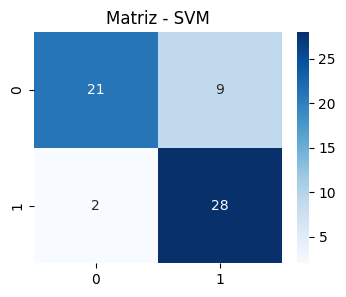


Random Forest
Train Accuracy : 1.0000
Test Accuracy  : 0.7833
Train Loss     : 0.0209
Test Loss      : 0.5275
              precision    recall  f1-score   support

           0       0.87      0.67      0.75        30
           1       0.73      0.90      0.81        30

    accuracy                           0.78        60
   macro avg       0.80      0.78      0.78        60
weighted avg       0.80      0.78      0.78        60



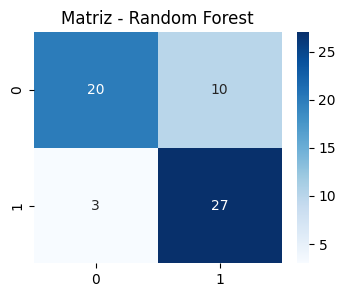


XGBoost
Train Accuracy : 1.0000
Test Accuracy  : 0.8167
Train Loss     : 0.0145
Test Loss      : 0.6146
              precision    recall  f1-score   support

           0       0.95      0.67      0.78        30
           1       0.74      0.97      0.84        30

    accuracy                           0.82        60
   macro avg       0.85      0.82      0.81        60
weighted avg       0.85      0.82      0.81        60



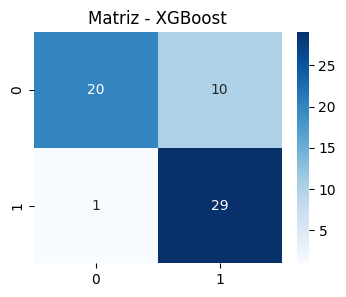


MLP
Train Accuracy : 1.0000
Test Accuracy  : 0.8333
Train Loss     : 0.0025
Test Loss      : 0.7466
              precision    recall  f1-score   support

           0       0.95      0.70      0.81        30
           1       0.76      0.97      0.85        30

    accuracy                           0.83        60
   macro avg       0.86      0.83      0.83        60
weighted avg       0.86      0.83      0.83        60



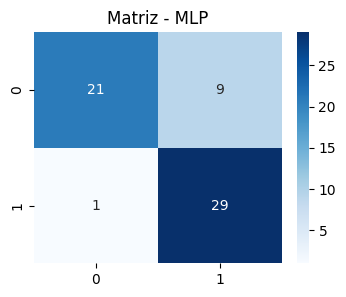

In [ ]:
results = []

results.append(

    evaluate_ml_model(

        svm,

        "SVM",

        X_train_ml,
        X_test_ml,

        y_train,
        y_test
    )
)

results.append(

    evaluate_ml_model(

        rf,

        "Random Forest",

        X_train_ml,
        X_test_ml,

        y_train,
        y_test
    )
)

results.append(

    evaluate_ml_model(

        xgb,

        "XGBoost",

        X_train_ml,
        X_test_ml,

        y_train,
        y_test
    )
)

results.append(

    evaluate_ml_model(

        mlp,

        "MLP",

        X_train_ml,
        X_test_ml,

        y_train,
        y_test
    )
)

In [ ]:
results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(

    by="MCC",

    ascending=False
)

results_df = results_df.reset_index(
    drop=True
)

display(results_df)

,Model,Train Accuracy,Test Accuracy,Train Loss,Test Loss,F1-Score,MCC,Recall,Precision
0,MLP,1.0,0.833333,0.002497,0.746593,0.852941,0.691714,0.966667,0.763158
1,XGBoost,1.0,0.816667,0.014462,0.614554,0.840580,0.663914,0.966667,0.743590
2,SVM,1.0,0.816667,NaN,NaN,0.835821,0.651312,0.933333,0.756757
3,Random Forest,1.0,0.783333,0.020895,0.527475,0.805970,0.582752,0.900000,0.729730


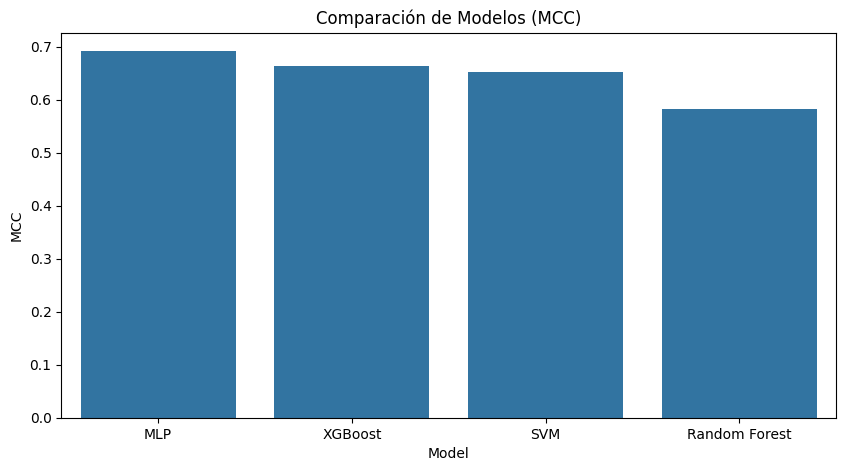

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results_df,

    x="Model",

    y="MCC"
)

plt.title(
    "Comparación de Modelos (MCC)"
)

plt.show()

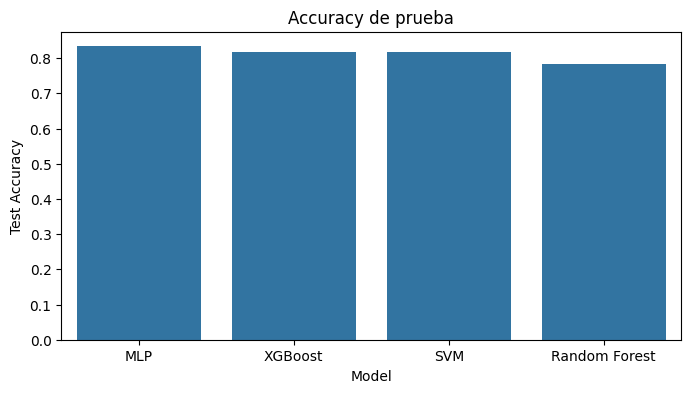

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=results_df,
    x="Model",
    y="Test Accuracy"
)
plt.title("Accuracy de prueba")
plt.show()

## Validación cruzada entre sujetos

In [ ]:
from sklearn.model_selection import GroupKFold

# MODELOS

models = {

    "SVM": SVC(
        kernel="rbf",
        C=10,
        gamma="scale"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(128,64),
        max_iter=500,
        random_state=42
    )
}

In [ ]:
#CICLO DE VALIDACION CRUZADA

gkf = GroupKFold(n_splits=5)

results_cv = []

for model_name, model in models.items():

    print("\n")
    print("="*60)
    print(model_name)
    print("="*60)

    fold_mcc = []
    fold_acc = []

    for fold, (train_idx, test_idx) in enumerate(

        gkf.split(
            X_ml,
            y_ml,
            groups_ml
        )

    ):

        X_train = X_ml[train_idx]
        X_test  = X_ml[test_idx]

        y_train = y_ml[train_idx]
        y_test  = y_ml[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        mcc = matthews_corrcoef(
            y_test,
            pred
        )

        acc = accuracy_score(
            y_test,
            pred
        )

        fold_mcc.append(mcc)
        fold_acc.append(acc)

        print(
            f"Fold {fold+1}: "
            f"ACC={acc:.4f} | "
            f"MCC={mcc:.4f}"
        )

    print("\nPromedios")

    print(
        f"ACC = {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}"
    )

    print(
        f"MCC = {np.mean(fold_mcc):.4f} ± {np.std(fold_mcc):.4f}"
    )

    results_cv.append({

        "Model": model_name,

        "ACC Mean": np.mean(
            fold_acc
        ),

        "ACC STD": np.std(
            fold_acc
        ),

        "MCC Mean": np.mean(
            fold_mcc
        ),

        "MCC STD": np.std(
            fold_mcc
        ),

        "Best ACC": np.max(
            fold_acc
        ),

        "Worst ACC": np.min(
            fold_acc
        ),

        "Best MCC": np.max(
            fold_mcc
        ),

        "Worst MCC": np.min(
            fold_mcc
        )
    })



SVM
Fold 1: ACC=0.8667 | MCC=0.7609
Fold 2: ACC=0.9500 | MCC=0.9045
Fold 3: ACC=0.7833 | MCC=0.5828
Fold 4: ACC=0.8500 | MCC=0.7099
Fold 5: ACC=0.8000 | MCC=0.6000

Promedios
ACC = 0.8500 ± 0.0587
MCC = 0.7116 ± 0.1172


Random Forest
Fold 1: ACC=0.9167 | MCC=0.8375
Fold 2: ACC=0.9667 | MCC=0.9354
Fold 3: ACC=0.9833 | MCC=0.9672
Fold 4: ACC=0.9000 | MCC=0.8072
Fold 5: ACC=0.8000 | MCC=0.6030

Promedios
ACC = 0.9133 ± 0.0645
MCC = 0.8301 ± 0.1281


XGBoost
Fold 1: ACC=0.9500 | MCC=0.9045
Fold 2: ACC=0.9167 | MCC=0.8452
Fold 3: ACC=0.9667 | MCC=0.9354
Fold 4: ACC=0.9333 | MCC=0.8686
Fold 5: ACC=0.8500 | MCC=0.7035

Promedios
ACC = 0.9233 ± 0.0403
MCC = 0.8514 ± 0.0801


MLP
Fold 1: ACC=0.8667 | MCC=0.7609
Fold 2: ACC=0.9667 | MCC=0.9354
Fold 3: ACC=0.8333 | MCC=0.6917
Fold 4: ACC=0.8333 | MCC=0.6917
Fold 5: ACC=0.8500 | MCC=0.7000

Promedios
ACC = 0.8700 ± 0.0499
MCC = 0.7559 ± 0.0934


## Ranking de generalización

In [ ]:
cv_results_df = pd.DataFrame(
    results_cv
)

cv_results_df = cv_results_df.sort_values(

    by="MCC Mean",

    ascending=False

).reset_index(
    drop=True
)

print("\n")
print("="*80)
print("RANKING DE GENERALIZACIÓN")
print("="*80)

display(
    cv_results_df.round(4)
)



RANKING DE GENERALIZACIÓN


,Model,ACC Mean,ACC STD,MCC Mean,MCC STD,Best ACC,Worst ACC,Best MCC,Worst MCC
0,XGBoost,0.9233,0.0403,0.8514,0.0801,0.9667,0.8500,0.9354,0.7035
1,Random Forest,0.9133,0.0645,0.8301,0.1281,0.9833,0.8000,0.9672,0.6030
2,MLP,0.8700,0.0499,0.7559,0.0934,0.9667,0.8333,0.9354,0.6917
3,SVM,0.8500,0.0587,0.7116,0.1172,0.9500,0.7833,0.9045,0.5828


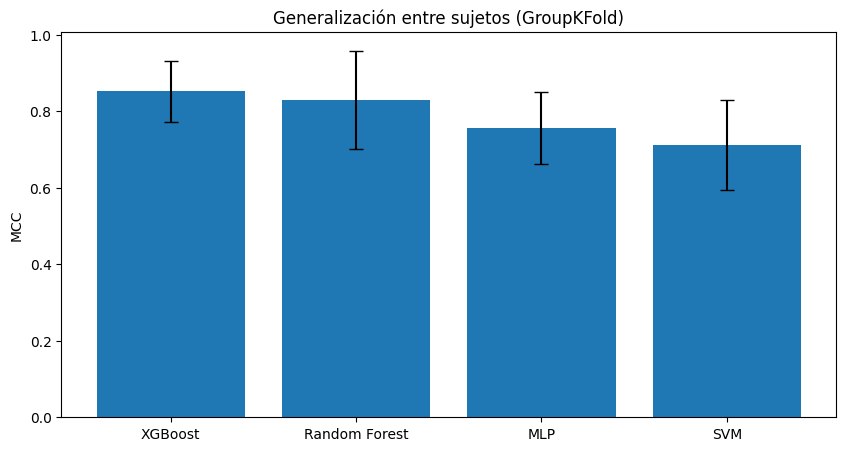

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["MCC Mean"],
    yerr=cv_results_df["MCC STD"],
    capsize=5
)

plt.ylabel("MCC")
plt.title("Generalización entre sujetos (GroupKFold)")
plt.show()

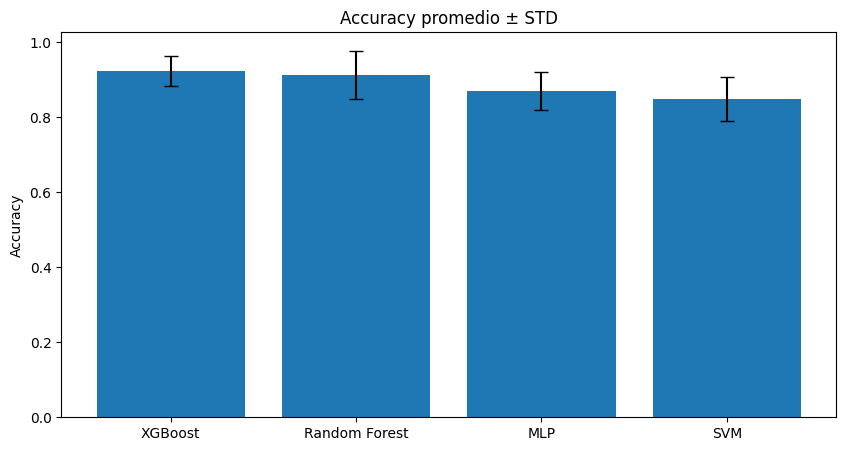

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["ACC Mean"],
    yerr=cv_results_df["ACC STD"],
    capsize=5
)

plt.ylabel("Accuracy")
plt.title("Accuracy promedio ± STD")
plt.show()

## Selección automática del mejor clasificador

In [ ]:
# MEJOR MODELO SEGÚN MCC PROMEDIO

best_model_name = cv_results_df.iloc[0]["Model"]

print("="*60)
print("MEJOR MODELO")
print("="*60)
print(best_model_name)

MEJOR MODELO
XGBoost


In [ ]:
# RECONSTRUIR EL MEJOR MODELO

if best_model_name == "SVM":

    best_model = SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        probability=True
    )

elif best_model_name == "Random Forest":

    best_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42
    )

elif best_model_name == "XGBoost":

    best_model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

elif best_model_name == "MLP":

    best_model = MLPClassifier(
        hidden_layer_sizes=(128,64),
        max_iter=500,
        random_state=42
    )

## Entrenamiento final del modelo seleccionado

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# ENTRENAR MODELO FINAL

X_train_ml_rederived = X_ml[train_idx]
y_train_rederived = y_ml[train_idx]

scaler_for_final_train = StandardScaler()
X_train_ml_scaled = scaler_for_final_train.fit_transform(X_train_ml_rederived)

best_model.fit(
    X_train_ml_scaled,
    y_train_rederived
)

print("\nModelo final entrenado correctamente.")


Modelo final entrenado correctamente.


# Generacion de recomendaciones

## Diccionarios de recomendaciones

In [ ]:
RECOMENDACIONES_LEVES = {

    "angulo_min_rodilla":
    "La ejecución fue adecuada; sin embargo, podría incrementar ligeramente la flexión de rodilla para aproximarse al patrón de referencia.",

    "angulo_min_cadera":
    "La técnica es correcta, aunque una mayor movilidad de cadera podría optimizar el movimiento.",

    "longitud_torso":
    "Mantenga una postura del tronco más consistente durante toda la ejecución.",

    "simetria_hombros":
    "La ejecución es adecuada; procure mejorar ligeramente la alineación de los hombros.",

    "simetria_caderas":
    "Puede mejorar la simetría de la pelvis para acercarse al patrón ideal.",

    "simetria_rodillas":
    "Existe una pequeña diferencia entre rodillas que puede corregirse.",

    "simetria_codos":
    "Puede mejorar la sincronización de ambos codos durante el movimiento.",

    "simetria_munecas":
    "Procure mantener una alineación más uniforme de las muñecas.",

    "max_dif_altura_hombros":
    "Se observa una leve diferencia de altura entre hombros.",

    "max_dif_altura_caderas":
    "Puede reducir ligeramente la inclinación lateral de la pelvis.",

    "max_dif_altura_rodillas":
    "Intente mantener ambas rodillas a una altura más uniforme.",

    "max_dif_altura_manos":
    "Existe una leve asimetría en la altura de las manos.",

    "max_dif_altura_munecas":
    "Puede mejorar la alineación vertical de las muñecas.",

    "max_inclinacion_hombros":
    "Reduzca ligeramente la inclinación lateral de los hombros.",

    "max_inclinacion_caderas":
    "Puede mejorar la estabilidad lateral de la pelvis.",

    "max_inclinacion_barra":
    "La barra presenta una ligera inclinación respecto al patrón de referencia.",

    "distancia_mano_rodilla":
    "Procure mantener la barra un poco más próxima al cuerpo.",

    "max_asimetria_brazos":
    "Puede mejorar la simetría del trabajo entre ambos brazos.",

    "max_asimetria_piernas":
    "Existe una leve diferencia en la distribución de carga entre piernas.",

    "max_desplazamiento_lateral":
    "Se observa un pequeño desplazamiento lateral del tronco.",

    "rom_codo":
    "Podría aumentar ligeramente el rango de movimiento del codo.",

    "velocidad_media_codo":
    "Una ejecución más uniforme podría mejorar la técnica.",

    "distancia_media_codo_hombro":
    "Puede mantener el codo un poco más próximo al tronco.",

    "distancia_media_codo_cadera":
    "Se recomienda reducir ligeramente el desplazamiento del brazo.",

    "desplazamiento_horizontal_barra":
    "La trayectoria de la barra podría ser algo más vertical.",

    "profundidad_descenso":
    "Puede optimizar la profundidad del descenso.",

    "ratio_pecho_abdomen":
    "La trayectoria de la barra puede ajustarse ligeramente.",

    "trayectoria_horizontal_barra":
    "Reduzca pequeños desplazamientos horizontales de la barra."
}

In [ ]:
RECOMENDACIONES = {

    "angulo_min_rodilla":
    "Intente aumentar la flexión de rodilla durante la fase descendente.",

    "angulo_min_cadera":
    "Mejore la movilidad y control de la cadera durante el movimiento.",

    "longitud_torso":
    "Mantenga una postura estable del tronco durante la ejecución.",

    "simetria_hombros":
    "Procure mantener ambos hombros alineados.",

    "simetria_caderas":
    "Mantenga una posición simétrica de la pelvis.",

    "simetria_rodillas":
    "Evite compensaciones entre ambas rodillas.",

    "simetria_codos":
    "Mantenga ambos codos trabajando de forma simétrica.",

    "simetria_munecas":
    "Procure mantener ambas muñecas alineadas.",

    "max_dif_altura_hombros":
    "Reduzca las diferencias de altura entre los hombros.",

    "max_dif_altura_caderas":
    "Evite inclinaciones laterales de la pelvis.",

    "max_dif_altura_rodillas":
    "Controle la estabilidad de ambas rodillas.",

    "max_dif_altura_manos":
    "Mantenga ambas manos a la misma altura.",

    "max_dif_altura_munecas":
    "Mantenga ambas muñecas a la misma altura.",

    "max_inclinacion_hombros":
    "Evite inclinaciones laterales excesivas de los hombros.",

    "max_inclinacion_caderas":
    "Procure mantener la pelvis nivelada.",

    "max_inclinacion_barra":
    "Mantenga la barra paralela al suelo.",

    "distancia_mano_rodilla":
    "Mantenga la barra cercana al cuerpo durante todo el recorrido.",

    "max_asimetria_brazos":
    "Mantenga ambos brazos trabajando de forma uniforme.",

    "max_asimetria_piernas":
    "Distribuya la carga de forma equilibrada entre ambas piernas.",

    "max_desplazamiento_lateral":
    "Evite desplazamientos laterales del tronco.",

    "rom_codo":
    "Aumente el rango de movimiento del codo.",

    "velocidad_media_codo":
    "Realice el movimiento de forma más controlada.",

    "distancia_media_codo_hombro":
    "Mantenga el codo más próximo al tronco.",

    "distancia_media_codo_cadera":
    "Evite desplazar el brazo respecto al tronco.",

    "desplazamiento_horizontal_barra":
    "Mantenga una trayectoria más vertical de la barra.",

    "profundidad_descenso":
    "Controle la profundidad del descenso.",

    "ratio_pecho_abdomen":
    "Procure descender la barra hacia una zona consistente del pecho.",

    "trayectoria_horizontal_barra":
    "Reduzca desplazamientos horizontales innecesarios de la barra."
}

## Generación de recomendaciones y evaluacion de video

In [ ]:
def generar_recomendaciones(
    detalle,
    calidad
):

    fuera_rango = detalle[
        detalle["Cumple"] == False
    ].copy()

    if len(fuera_rango) == 0:

        return pd.DataFrame({

            "Parametro": ["Sin observaciones"],

            "Recomendacion": [
                "Todos los indicadores biomecánicos se encuentran dentro de los rangos de referencia."
            ]
        })

    fuera_rango = fuera_rango.sort_values(
        by="Desviacion",
        ascending=False
    )

    # Si la ejecución fue correcta,
    # mostrar máximo 2 observaciones leves

    if calidad == "Correcta":

        fuera_rango = fuera_rango.head(2)

        recomendaciones = []

        for _, row in fuera_rango.iterrows():

            parametro = row["Parametro"]

            if parametro in RECOMENDACIONES_LEVES:

                recomendaciones.append({

                    "Parametro": parametro,

                    "Recomendacion":
                    RECOMENDACIONES_LEVES[parametro]
                })

        return pd.DataFrame(recomendaciones)

    # Si fue incorrecta se usan recomendaciones correctivas

    recomendaciones = []

    for _, row in fuera_rango.iterrows():

        parametro = row["Parametro"]

        if parametro in RECOMENDACIONES:

            recomendaciones.append({

                "Parametro": parametro,

                "Recomendacion":
                RECOMENDACIONES[parametro]
            })

    return pd.DataFrame(recomendaciones)

In [ ]:
def evaluar_video(
    video,
    df_pivot,
    modelo_referencia,
    modelo_final,
    scaler_final,
    ejercicio,
    vista
):

    data_video = df_pivot[
        df_pivot["video"] == video
    ]

    # Indicadores biomecánicos

    indicadores = extraer_indicadores_video(
        data_video,
        ejercicio,
        vista
    )

    detalle, score_biomecanico = comparar_con_modelo(
        indicadores,
        modelo_referencia
    )

    # Construcción del vector ML

    feature_vector = []

    cumple_total = 0

    for _, row in modelo_referencia.iterrows():

        parametro = row["Parametro"]

        ideal = row["Valor ideal"]

        inferior = row["Limite inferior"]

        superior = row["Limite superior"]

        valor = indicadores[parametro]

        desviacion = abs(
            valor - ideal
        )

        desviacion_relativa = (
            desviacion /
            (abs(ideal) + 1e-6)
        )

        cumple = int(
            inferior <= valor <= superior
        )

        feature_vector.extend([

            valor,

            desviacion,

            desviacion_relativa,

            cumple

        ])

        cumple_total += cumple

    porcentaje_cumplimiento = (

        cumple_total
        /
        len(modelo_referencia)

    )

    feature_vector.extend([

        score_biomecanico,

        porcentaje_cumplimiento

    ])

    X_video = np.array(
        feature_vector
    ).reshape(1,-1)

    X_video = scaler_final.transform(
        X_video
    )

    # Clasificación

    pred = modelo_final.predict(
        X_video
    )[0]

    calidad = (
        "Correcta"
        if pred == 1
        else "Incorrecta"
    )

    if hasattr(modelo_final, "predict_proba"):

        confianza = np.max(
            modelo_final.predict_proba(
                X_video
            )
        )

    else:

        confianza = None

    print("Predicción:", pred)
    print("Calidad:", calidad)

    # Recomendaciones

    recomendaciones = generar_recomendaciones(
        detalle,
        calidad
    )

    return {

        "video": video,

        "score_biomecanico":
        score_biomecanico,

        "calidad":
        calidad,

        "confianza":
        confianza,

        "detalle":
        detalle,

        "recomendaciones":
        recomendaciones
    }

## Mejor modelo de clasificación

In [ ]:
best_model.fit(
    X_train_ml_scaled,
    y_train_rederived
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
modelo_final = best_model
scaler_final = scaler_for_final_train

## Prueba con video aleatorio

In [ ]:
# VIDEO ALEATORIO

video_prueba = np.random.choice(
    df_pivot["video"].unique()
)

resultado = evaluar_video(

    video_prueba,

    df_pivot,

    modelo_referencia,

    modelo_final,

    scaler_final,

    ejercicio,

    vista
)

Predicción: 1
Calidad: Correcta


In [ ]:
print("VIDEO EVALUADO")

print(resultado["video"])

print("\nScore biomecánico:")
print(
    f"{resultado['score_biomecanico']:.2f}%"
)

print("\nClasificación:")

print(
    resultado["calidad"]
)

if resultado["confianza"] is not None:

    print(
        f"Confianza: "
        f"{100*resultado['confianza']:.2f}%"
    )

print("\nRECOMENDACIONES")

display(
    resultado["recomendaciones"]
)

VIDEO EVALUADO
2_RodriguezGregory_Sentadilla_Frontal_Bien_Rep_2.mp4

Score biomecánico:
89.40%

Clasificación:
Correcta
Confianza: 99.65%

RECOMENDACIONES


,Parametro,Recomendacion
0,simetria_hombros,La ejecución es adecuada; procure mejorar lige...
1,simetria_caderas,Puede mejorar la simetría de la pelvis para ac...
